# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [138]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.14.6 | pandas: 2.3.3


## 1. Target and audit
State the prediction moment, unit, population and target. Distinguish final classification from completing a race. Explain the source limitations. TO COMPLETE.

In [139]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

Add checks for duplicate keys, qualifying-only records, missing values and coverage. Explain what would happen with an inner join. TO COMPLETE.

In [140]:
duplicates = train.duplicated().sum()
null_cols = train.columns[train.isna().any()]
count_rows = train.shape[0]

print(f"Number of duplicate rows: {duplicates}")
print(f"Columns with missing values: {null_cols.tolist()}")
print(f"Total number of rows in the dataset: {count_rows}")

Number of duplicate rows: 0
Columns with missing values: ['qualifying_position']
Total number of rows in the dataset: 1200


We analized the dataset and we decided to drop the rows, a

## 2. EDA question 1
Question: How well does qualifying position anticipate a top-ten finish?

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

,Drivers,Finished top 10,Top-10 rate
Qualifying position,,,
1,60,57,95.0%
2,60,52,86.7%
3,60,50,83.3%
4,60,52,86.7%
5,60,44,73.3%
6,60,45,75.0%
7,60,43,71.7%
8,60,34,56.7%
9,60,40,66.7%


Rows without qualifying (excluded from this table): 3


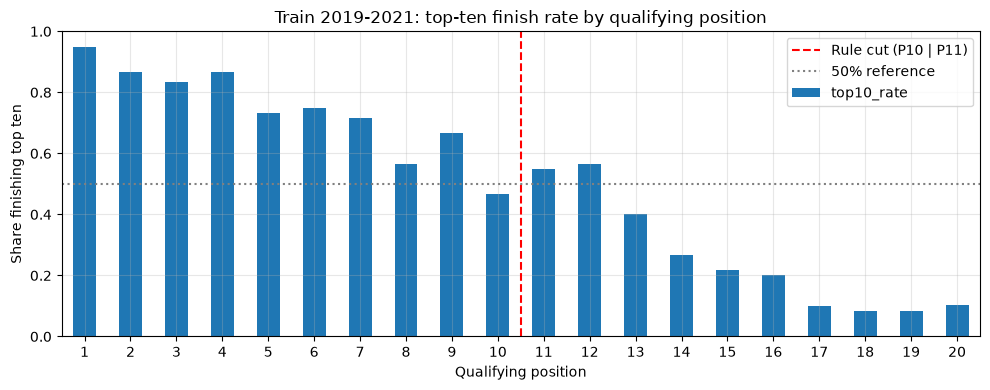

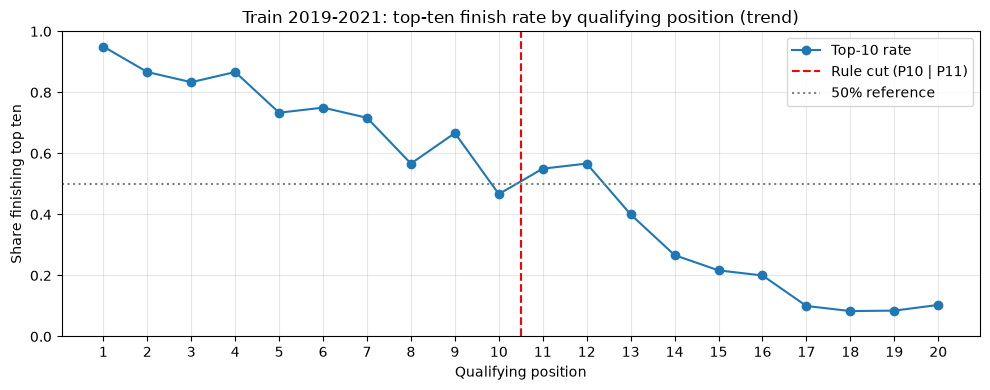

In [157]:
## Q1: top-ten rate for each qualifying position (train 2019-2021 only)
stats_q1 = (train
            .groupby('qualifying_position')['target_top10']
            .agg(drivers='count', finished_top10='sum', top10_rate='mean'))
stats_q1.index = stats_q1.index.astype(int)

## readable copy for display only, the numeric one stays for the chart
table_q1 = stats_q1.copy()
table_q1.index.name = 'Qualifying position'
table_q1['top10_rate'] = (table_q1['top10_rate'] * 100).round(1).astype(str) + '%'
table_q1.columns = ['Drivers', 'Finished top 10', 'Top-10 rate']
display(table_q1)

## groupby drops NaN keys, so the 3 rows without qualifying are NOT in this table
n_missing_quali = train['qualifying_position'].isna().sum()
print(f"Rows without qualifying (excluded from this table): {n_missing_quali}")

## bar chart: y fixed 0-1 so the drop isn't exaggerated, dashed line = the rule's cut
fig, ax = plt.subplots(figsize=(10, 4))
stats_q1['top10_rate'].plot(kind='bar', ax=ax, color='#1f77b4')
ax.axvline(9.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position')
ax.tick_params(axis='x', rotation=0)  ## keeps position labels horizontal
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## line chart: same data, easier to see the overall trend across positions
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(stats_q1.index, stats_q1['top10_rate'], marker='o', color='#1f77b4', label='Top-10 rate')
ax.axvline(10.5, color='red', linestyle='--', label='Rule cut (P10 | P11)')
ax.axhline(0.5, color='gray', linestyle=':', label='50% reference')
ax.set_xticks(stats_q1.index)  ## show every position 1-20 on the x-axis
ax.set_ylim(0, 1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Share finishing top ten')
ax.set_title('Train 2019-2021: top-ten finish rate by qualifying position (trend)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [155]:
# on position 19 and 20, there are 59 and 58 drivers, this is because the dataset contained nulls in qualifying_position, which were dropped by the groupby. The remaining 3 rows without qualifying are not included in this table.

## 3. EDA question 2
Question: TO COMPLETE.

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

In [141]:
# Add your train-only analysis here.    

## 4. EDA question 3
Question: TO COMPLETE.

Use train only. Add a table/graph, cite observed values, interpret and state a decision or limitation. At least one of the three analyses must check a Friday trap.

In [142]:
# Add your train-only analysis here.

## 5. Baselines and 2022 check
Explain the two fixed rules, tie handling and missing-qualifying fallback. Predict qualitatively how each might fail before running the check. TO COMPLETE.

In [143]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


Interpret TN/FP/FN/TP, accuracy and balanced accuracy. Explain the positive/negative error costs in this task without inventing monetary values. Record any corrections after the check. TO COMPLETE.

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- Members and date: TO COMPLETE.
- Target, population, join and prediction moment: TO COMPLETE.
- Baselines, train majority, threshold and missing policy: TO COMPLETE.
- Three analysis decisions and changes after calibration: TO COMPLETE.
- Frozen code commit/version: TO COMPLETE.

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [144]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test remains unopened by this notebook. Complete and commit the freeze record first.


## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation. TO COMPLETE.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.